In [ ]:
import seaborn as sns
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Fetch file id on Drive
file_id = "1fNiz9QRSD5drWAs3k1Ji09D_u3COOJWR"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
gdown.download(url, "bank_transactions.csv", quiet=True)

# Load url
bank_df = pd.read_csv("bank_transactions.csv")

<br></br>

### Building K-Means Model (Customer Segmentation) to:
- Profile customer groups
- Visualize clusters

In [ ]:
# Segmentation features
features = ['CustomerAge', 'AccountBalance', 'TransactionAmount', 'TransactionDuration', 'LoginAttempts']
X = bank_df[features]


In [ ]:
# Scale features(K-Means is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

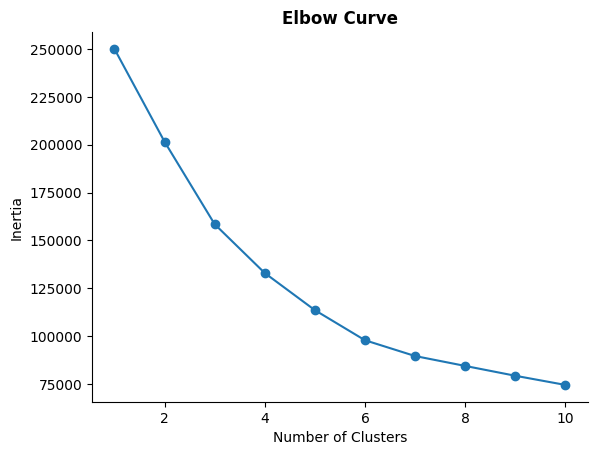

In [ ]:
# Find optimal K (Elbow method)
inertia = []

for k in range(1,11):
  kmeans = KMeans(n_clusters= k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Curve", fontweight="bold")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [ ]:
# Find optimal k (Silhouette method)
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}: {score:.3f}")

K=2: 0.227
K=3: 0.252
K=4: 0.261
K=5: 0.252
K=6: 0.266
K=7: 0.240
K=8: 0.242
K=9: 0.235
K=10: 0.244


In [ ]:
# Build model with optimal k = 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Create new cluster column
bank_df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
# Profile the clusters
cluster_profile = bank_df.groupby('Cluster')[features].mean().round(3).reset_index()
print(cluster_profile)

   Cluster  CustomerAge  AccountBalance  TransactionAmount  \
0        0       28.008        1946.507            232.699   
1        1       55.339        7195.737            193.301   
2        2       44.358        5245.513            270.140   
3        3       47.273        5445.508            885.373   

   TransactionDuration  LoginAttempts  
0              118.569          1.009  
1              119.325          1.012  
2              131.016          4.021  
3              114.982          1.012  


### Cluster 0 : Young Banking Users
- Youngest customers
- Lowest balances
- Small-to-moderate transaction amounts
- Minimal login issues

These customers appear to use their accounts primarily for routine banking activities and maintain relatively low balances.

### Cluster 1: High-Balance Conservative Customers
- Oldest customers
- Highest account balances
- Lowest transaction amounts
- Stable access patterns

Customers maintain substantial balances but engage in relatively small transactions, suggesting a savings-oriented rather than transaction-heavy profile.

### Cluster 2: Digitally Active Customers
This segment exhibits significantly higher login activity than all other customer groups, indicating frequent account monitoring, repeated authentication attempts, or increased digital engagement.

### Cluster 3: High-Value Transaction Customers
Customers maintain moderate account balances but conduct significantly larger transactions than other segments, indicating higher transactional intensity.

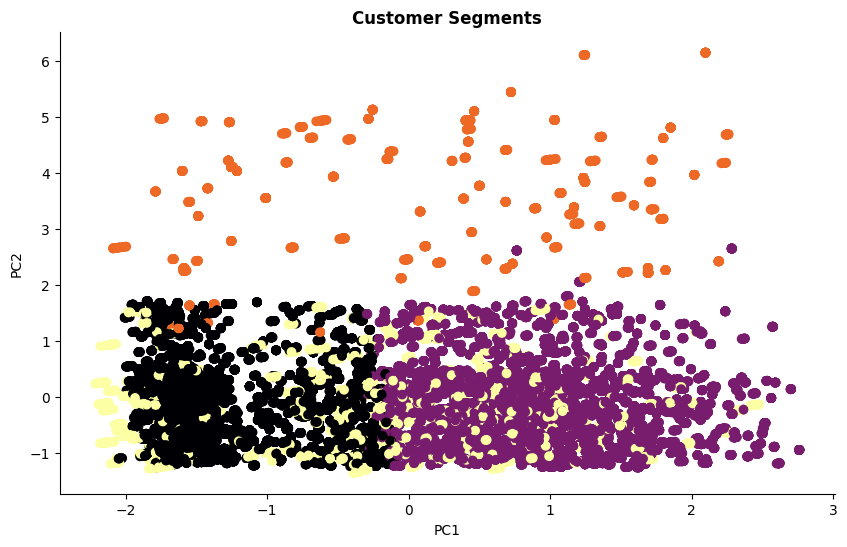

In [ ]:
# Visualize clusters with PCA
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))

plt.scatter(pca_features[:,0], pca_features[:,1], c=bank_df['Cluster'], cmap='inferno')
plt.title('Customer Segments', fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

- PCA visualization confirmed the presence of four customer segments identified by K-Means clustering.
- The first principal component primarily differentiated younger customers with lower account balances from older customers with higher balances.
- The second principal component strongly separated customers showing high login activity.
- A fourth segment characterized by higher transaction amounts showed some overlap in the two-dimensional projection, suggesting its distinction is captured in higher-order components not fully represented by PC1 and PC2.